# Hierarchical mergers of binary black holes

All the relevant information for the project are to be found in the pdf document present in the repo.
Note that you are assigned to project 2 (as the title said).

## Datasets 

Datasets are stored on Google Drive (link and description in the pdf document)

### Contacts

* Giuliano Iorio <giuliano.iorio@unipd.it>


## Libraries 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np


## Data load

Here we load the different files containing all the data that we will use for this project. We will merge all data in to one large file adding flags to the nature of the system and to the metallicitty so we don't loose information. This will make it easier in order to make an exploratory analysis

In [ ]:
# uncomment and run this code block to read and combine all nth_generation.txt files into a single DataFrame

#def read_nth_generation(path):
#    # read and repair header (merge tokens that start with '(' into previous token)
#    with open(path, 'r') as f:
#        header = f.readline().strip()
#    tokens = header.split()
#    names = []
#    for tok in tokens:
#        if tok.startswith('(') and names:
#            names[-1] = names[-1] + ' ' + tok
#        else:
#            names.append(tok)
#    # read remaining rows using whitespace splitting and assign repaired names
#    df = pd.read_csv(path, sep='\s+', header=None, names=names, skiprows=1, comment='#')
#    return df
#
#base_path = Path('fastcluster_comp_physA')
#all_data = []
#for filepath in base_path.glob('**/*/Dyn/*/nth_generation.txt'):
#    sys_origin = filepath.parts[-4].split('_')[0]
#    mettalictty = float(filepath.parts[-2])
#    df = read_nth_generation(filepath)
#    df['sys'] = sys_origin
#    df['met'] = mettalictty
#    all_data.append(df)
#
#df_final = pd.concat(all_data, ignore_index=True, sort=False)

Now we drop the columns that have no useful information for our classification task

In [ ]:
# after running the above code block once, you can comment it out and read the combined CSV file directly in the future, uncomment the following lines to drop unnecessary columns,
#  convert identifier to category, and save the cleaned DataFrame to a new CSV file. You can also inspect the columns and data types before saving.:


#df_final.drop(columns=['c5:theta1', 'c6:theta2', 'c7:SMA(Rsun)', 'c8:ecc','c10:SMAfin(cm)', 'c11:eccfin',
#       'c12:tpeters/Myr', 'c14:vkick/kms', 'c18:flag1', 'c19:flag2', 'c20:flag3', 'c21:flagSN', 'c22:flag_exch',
#       'c23:flag_t3bb', 'c24:flag_evap','c26:ecc(10Hz)'], inplace=True)
#df_final['c0:identifier'] = df_final['c0:identifier'].astype('category')
#df_final.columns
#df_final.to_csv('combined_nth_generation.csv', index=False)
df_final = pd.read_csv('combined_nth_generation.csv')

Now we separate the data into three different dataframes according to the type of system they belong to, this will make it easier incase we want to analyze the data in a same group

In [ ]:
df_GC = df_final[df_final['sys'] == 'GC'] 
df_NSC = df_final[df_final['sys'] == 'NSC']
df_YSC = df_final[df_final['sys'] == 'YSC']

## Exploratory Data Analysis (EDA)

Now we will perform an exploration of the different parameters to detect some outliers and clean the datasets in order to make sure we have consistent measurements. 

In [ ]:
print(df_final.columns)
print(df_final.shape)

In [ ]:
#from ydata_profiling import ProfileReport

In [ ]:
#profile_GC = ProfileReport(df_GC, title="Profiling Report for GC", explorative=True)
#profile_GC.to_file("GC_report.html")
#profile_YSC = ProfileReport(df_YSC, title="Profiling Report for YSC", explorative=True)
#profile_YSC.to_file("YSC_report.html")
#profile_NSC = ProfileReport(df_NSC, title="Profiling Report for NSC", explorative=True)
#profile_NSC.to_file("NSC_report.html")
#profile_total = ProfileReport(df_final, title="Profiling Report for total dataset", explorative=True)
#profile_total.to_file("total_report.html")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def advanced_joint_plot(df, x_col, y_col, hue_color, hue_style):
    # --- PRE-CALCULATION ---
    # Calculate limits based on 90th percentile for visualization
    x_limit = df[x_col].quantile(0.90)
    y_limit = df[y_col].quantile(0.90)
    
    

    # 1. Initialize the JointGrid
    g = sns.JointGrid(data=df, x=x_col, y=y_col, hue=hue_color, palette="Set2")

    # 2. Add Scatter Plot (Using Sampled Data)
    sns.scatterplot(
        data=df, x=x_col, y=y_col, 
        hue=hue_color, style=hue_style, 
        ax=g.ax_joint, palette="Set2", alpha=0.4, s=15
    )

    # 3. Add KDE plot (Using Sampled Data for speed)
    sns.kdeplot(
        data=df, x=x_col, y=y_col, 
        hue=hue_color, ax=g.ax_joint, 
        palette="Set2", levels=3, alpha=1, warn_singular=True
    )

    # 4. Add Histograms to Margins (Using FULL Data for accuracy)
    sns.histplot(
        data=df, x=x_col, hue=hue_color, element="step",
        ax=g.ax_marg_x, palette="Set2", legend=False, common_norm=False,
        binrange=(df[x_col].min(), x_limit) # Clips bins to the 90th percentile
    )
    
    sns.histplot(
        data=df, y=y_col, hue=hue_color, element="step",
        ax=g.ax_marg_y, palette="Set2", legend=False, common_norm=False,
        binrange=(df[y_col].min(), y_limit) # Clips bins to the 90th percentile
    )

    # 5. Add Mean Lines (Calculated from Full Data)
    x_mean = df[x_col].mean()
    y_mean = df[y_col].mean()

    # Note: If the mean is > 90th percentile, it won't show in the zoomed plot
    g.ax_marg_x.axvline(x_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {x_mean:.2f}')
    g.ax_marg_y.axhline(y_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {y_mean:.2f}')

    # --- AXIS LIMITS ---
    # Apply the 90th percentile limits to the joint axis
    g.ax_joint.set_xlim(df[x_col].min(), x_limit)
    g.ax_joint.set_ylim(df[y_col].min(), y_limit)

    # Move legend
    g.ax_joint.legend(bbox_to_anchor=(1.25, 1), loc='upper left', borderaxespad=0)
    
    return g

# Example usage:
# Sample 100k rows while keeping the 'sys' distribution identical to the original
df_sample = df_final.groupby('sys', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 50000), random_state=42)
)

# Now use df_sample in your advanced_joint_plot function
g = advanced_joint_plot(df_sample, 'c1:M1/Msun', 'c17:vesc/kms', 'sys', 'c27:Ngen')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def triple_joint_plot(dfs, labels, x_col, y_col, hue_col, palette="Set2", quantile=1):
    """
    dfs: List of 3 dataframes [df1, df2, df3]
    labels: List of names ['Train', 'Val', 'Test']
    x_col/y_col: columns to plot
    hue_col: Column for color within each dataset
    """
    markers = ['o', 's', '^'] # Circle, Square, Triangle for the 3 datasets
    
    # 1. Calculate Global 90th percentile across all data for consistent axis limits
    all_data_x = pd.concat([d[x_col] for d in dfs])
    all_data_y = pd.concat([d[y_col] for d in dfs])
    x_limit = all_data_x.quantile(quantile)
    y_limit = all_data_y.quantile(quantile)
    x_min, y_min = all_data_x.min(), all_data_y.min()

    # 2. Initialize the Grid (we use the first DF just to set up the axes)
    g = sns.JointGrid()

    # 3. Loop through datasets to plot
    for i, df in enumerate(dfs):
        color_palette = sns.color_palette(palette, n_colors=len(df[hue_col].unique()))
        
        # --- Center Scatter & KDE ---
        # Sample for performance (Safety first!)
        df_sample = df.sample(n=min(len(df), 30000), random_state=42)
        
        sns.scatterplot(data=df_sample, x=x_col, y=y_col, hue=hue_col, 
                        marker=markers[i], ax=g.ax_joint, alpha=0.4, 
                        palette=color_palette, legend=(i == 0))
        
        sns.kdeplot(data=df_sample, x=x_col, y=y_col, hue=hue_col, 
                    ax=g.ax_joint, palette=color_palette, levels=2, 
                    alpha=1, warn_singular=True, legend=False)

        # --- Marginal Histograms ---
        sns.histplot(data=df, x=x_col, hue=hue_col, element="step", 
                     ax=g.ax_marg_x, palette=color_palette, legend=False, 
                     common_norm=False, binrange=(x_min, x_limit), alpha=0.2)
        
        sns.histplot(data=df, y=y_col, hue=hue_col, element="step", 
                     ax=g.ax_marg_y, palette=color_palette, legend=False, 
                     common_norm=False, binrange=(y_min, y_limit), alpha=0.2)

        # --- Mean Lines ---
        x_mean = df[x_col].mean()
        y_mean = df[y_col].mean()
        # Each dataset gets a different line style for its mean
        line_styles = ['-', '--', ':']
        g.ax_marg_x.axvline(x_mean, color='red', linestyle=line_styles[i], 
                            label=f'{labels[i]} Mean X: {x_mean:.2f}')
        g.ax_marg_y.axhline(y_mean, color='red', linestyle=line_styles[i], 
                            label=f'{labels[i]} Mean Y: {y_mean:.2f}')

    # 4. Final Formatting
    g.ax_joint.set_xlim(x_min, x_limit)
    g.ax_joint.set_ylim(y_min, y_limit)
    
    # Create a clean legend
    g.ax_joint.legend(title="Datasets & Categories", bbox_to_anchor=(1.25, 1), loc='upper left')
    
    return g

# Usage:
g = triple_joint_plot([df_GC, df_YSC, df_NSC], ['GC', 'YSC', 'NSC'], 'c1:M1/Msun', 'c17:vesc/kms', 'met')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def triple_joint_plot_threshold(dfs, labels, x_col, y_col, hue_col, threshold, palette=["#3498db", "#e74c3c"], quantile=1):
    """
    dfs: List of 3 dataframes
    labels: List of names for the 3 dataframes
    hue_col: The numerical column used for splitting
    threshold: The value to split the hue_col on
    palette: Two colors [Color_Low, Color_High]
    """
    markers = ['o', 's', '^'] # Different shapes for the 3 datasets
    
    # 1. Global statistics for axis limits (90th percentile)
    all_data_x = pd.concat([d[x_col] for d in dfs])
    all_data_y = pd.concat([d[y_col] for d in dfs])
    x_limit = all_data_x.quantile(quantile)
    y_limit = all_data_y.quantile(quantile)
    x_min, y_min = all_data_x.min(), all_data_y.min()

    # 2. Initialize Grid
    g = sns.JointGrid()

    # 3. Process each dataset
    for i, df in enumerate(dfs):
        # Create the binary category on the fly
        temp_df = df.copy()
        binary_label = f"{hue_col}_split"
        temp_df[binary_label] = np.where(temp_df[hue_col] <= threshold, 
                                         f"<= {threshold}", 
                                         f"> {threshold}")
        
        # Sampling for the scatter/KDE (performance)
        df_sample = temp_df.sample(n=min(len(temp_df), 30000), random_state=42)
        
        # Center Plot: Scatter + KDE
        sns.scatterplot(data=df_sample, x=x_col, y=y_col, hue=binary_label, 
                        marker=markers[i], ax=g.ax_joint, alpha=0.03, 
                        palette=palette, legend=(i == 0))
        
        sns.kdeplot(data=df_sample, x=x_col, y=y_col, hue=binary_label, 
                    ax=g.ax_joint, palette=palette, levels=2, 
                    alpha=1, warn_singular=True, legend=False)

        # Marginal Histograms (using full data)
        sns.histplot(data=temp_df, x=x_col, hue=binary_label, element="step", 
                     ax=g.ax_marg_x, palette=palette, legend=False, 
                     common_norm=False, binrange=(x_min, x_limit), alpha=0.15)
        
        sns.histplot(data=temp_df, y=y_col, hue=binary_label, element="step", 
                     ax=g.ax_marg_y, palette=palette, legend=False, 
                     common_norm=False, binrange=(y_min, y_limit), alpha=0.15)

        # Mean Lines per dataset (using original data)
        x_mean = df[x_col].mean()
        y_mean = df[y_col].mean()
        line_styles = ['-', '--', ':']
        g.ax_marg_x.axvline(x_mean, color='black', linestyle=line_styles[i], alpha=0.6,
                            label=f'{labels[i]} Mean')
        g.ax_marg_y.axhline(y_mean, color='black', linestyle=line_styles[i], alpha=0.6)

    # 4. Final Polish
    g.ax_joint.set_xlim(x_min, x_limit)
    g.ax_joint.set_ylim(y_min, y_limit)
    g.ax_joint.legend(title=f"Split by {hue_col}", bbox_to_anchor=(1.2, 1))
    
    return g
g = triple_joint_plot_threshold([df_GC, df_YSC, df_NSC], ['GC', 'YSC', 'NSC'], 'c1:M1/Msun', 'c17:vesc/kms', 'c27:Ngen',2)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def matrix_joint_plot(dfs, labels, x_col, y_col, hue_col):
    # 1. Setup global parameters
    unique_categories = sorted(pd.concat([d[hue_col] for d in dfs]).unique())
    num_datasets = len(dfs)
    num_cats = len(unique_categories)
    
    # Global limits (90th percentile) for consistent comparison across all plots
    all_x = pd.concat([d[x_col] for d in dfs])
    all_y = pd.concat([d[y_col] for d in dfs])
    x_lim = all_x.quantile(0.90)
    y_lim = all_y.quantile(0.90)
    
    # Dataset colors
    dataset_colors = ["#3498db", "#e74c3c", "#2ecc71"] # Blue, Red, Green

    # 2. Create the figure grid
    # We use a large figure size to accommodate the subplots
    fig = plt.figure(figsize=(4 * num_cats, 4 * num_datasets))
    
    # 3. Nested loop: Row = Dataset, Column = Category
    for d_idx, df in enumerate(dfs):
        for c_idx, cat in enumerate(unique_categories):
            # Filter data for this specific subplot
            subset = df[df[hue_col] == cat]
            
            # Skip if subset is empty to avoid crashing
            if subset.empty:
                continue
                
            # Create a JointGrid at the specific position
            # We calculate the position manually in the large figure
            inner_g = sns.JointGrid(data=subset, x=x_col, y=y_col, height=4)
            
            # Sampling for the scatter (Safety for 3.2M rows)
            sub_sample = subset.sample(n=min(len(subset), 10000), random_state=42)
            
            # Plot center
            inner_g.ax_joint.scatter(sub_sample[x_col], sub_sample[y_col], 
                                     color=dataset_colors[d_idx], alpha=0.3, s=5)
            sns.kdeplot(data=sub_sample, x=x_col, y=y_col, ax=inner_g.ax_joint, 
                        color="black", alpha=0.4, levels=3)
            
            # Plot margins
            sns.histplot(data=subset, x=x_col, ax=inner_g.ax_marg_x, 
                         color=dataset_colors[d_idx], element="step", fill=True)
            sns.histplot(data=subset, y=y_col, ax=inner_g.ax_marg_y, 
                         color=dataset_colors[d_idx], element="step", fill=True)
            
            # Set consistent limits
            inner_g.ax_joint.set_xlim(all_x.min(), x_lim)
            inner_g.ax_joint.set_ylim(all_y.min(), y_lim)
            
            # Add Titles only to the top row and left column for cleanliness
            if d_idx == 0:
                inner_g.ax_marg_x.set_title(f"Category: {cat}", fontweight='bold')
            if c_idx == 0:
                inner_g.ax_joint.set_ylabel(f"{labels[d_idx]}\n\n{y_col}")

    plt.tight_layout()
    return fig

# Usage:
fig = matrix_joint_plot([df_GC, df_YSC, df_NSC], ['GC', 'YSC', 'NSC'], 'c1:M1/Msun', 'c17:vesc/kms', 'met')

In [ ]:
fig = matrix_joint_plot([df_GC, df_YSC, df_NSC], ['GC', 'YSC', 'NSC'], 'c1:M1/Msun', 'c17:vesc/kms', 'c27:Ngen')

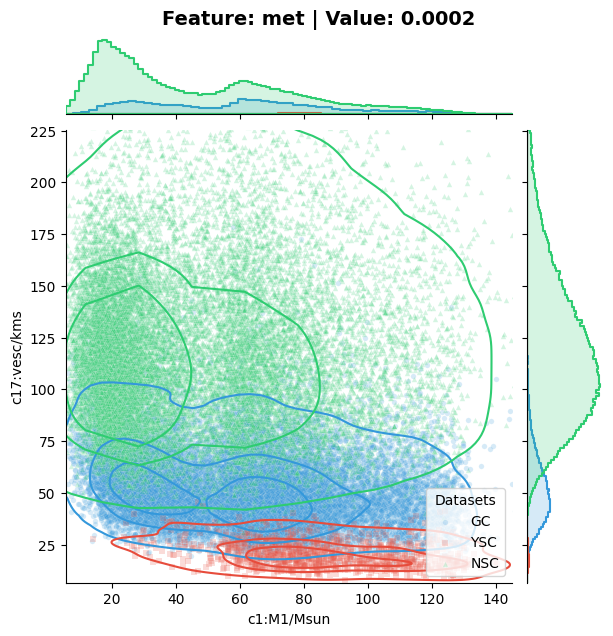

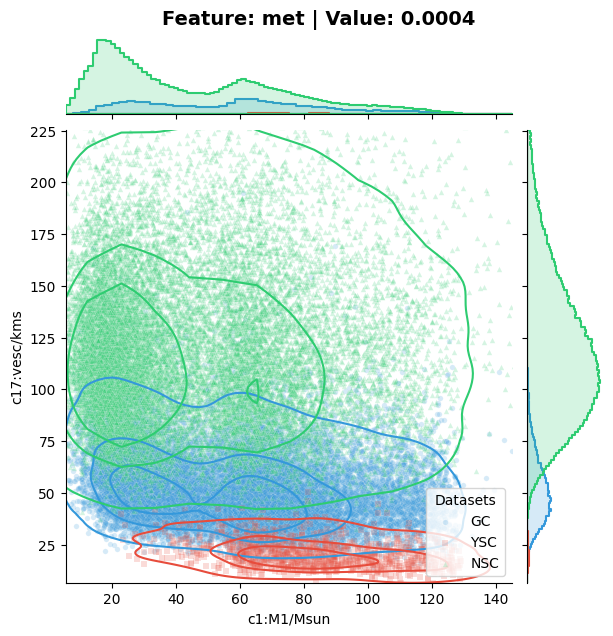

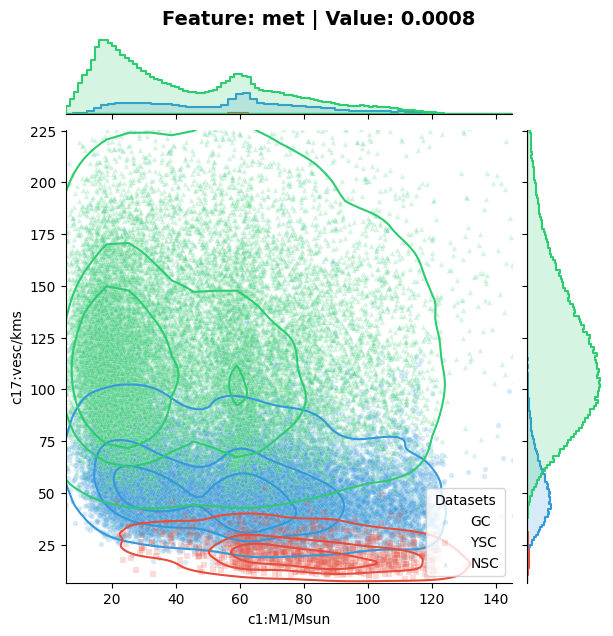

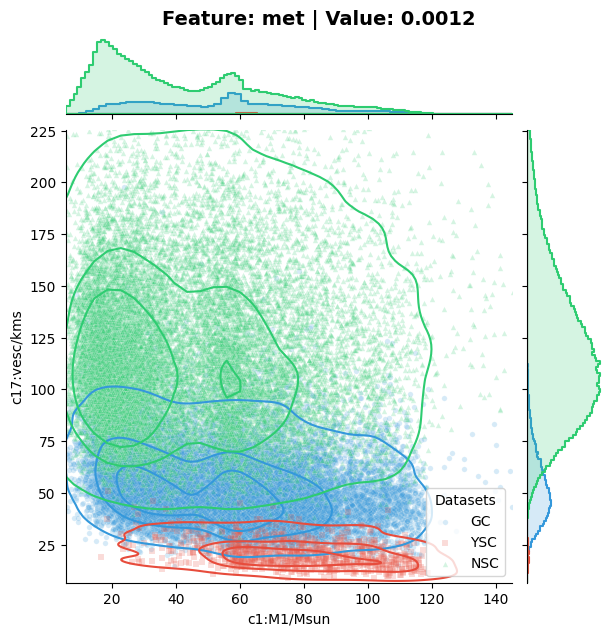

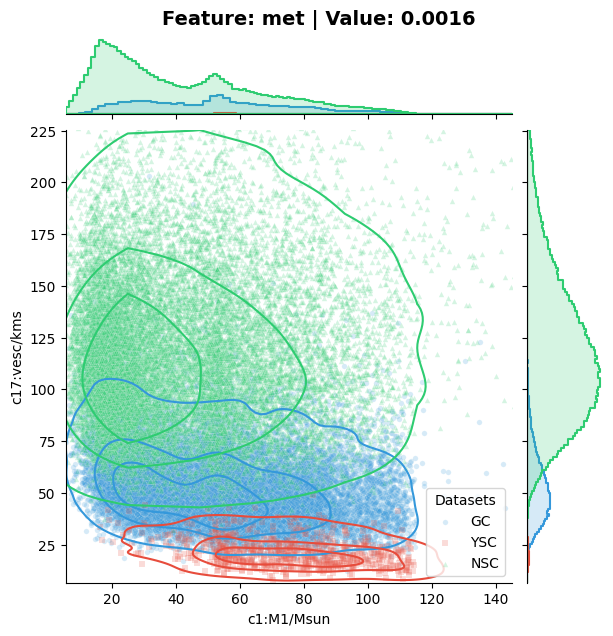

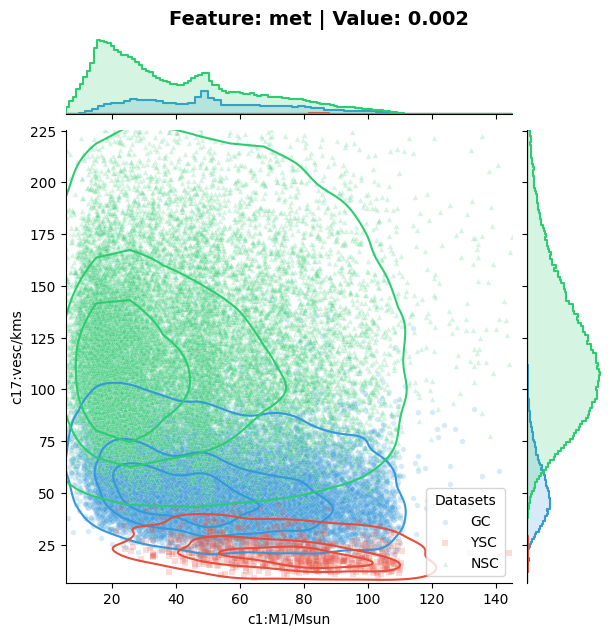

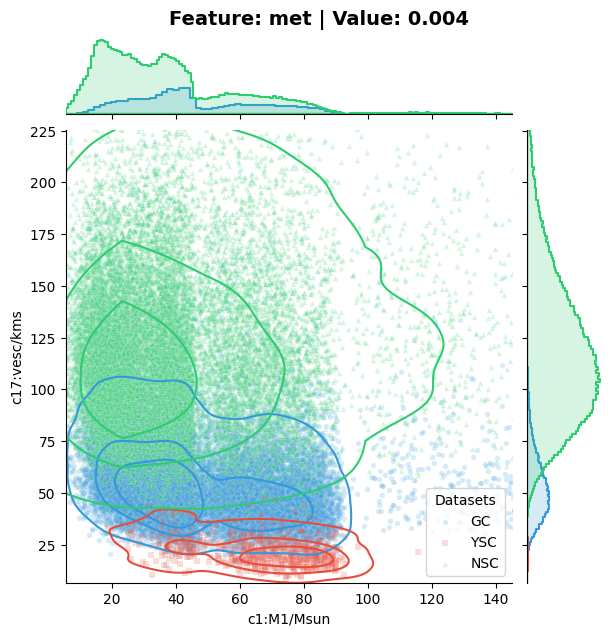

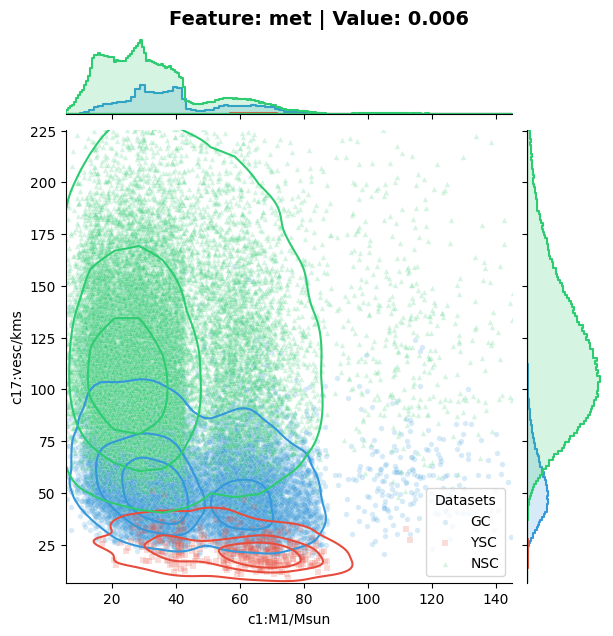

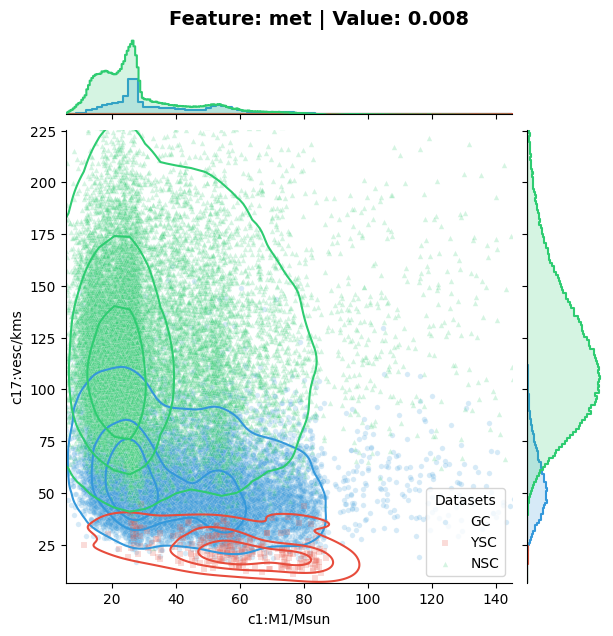

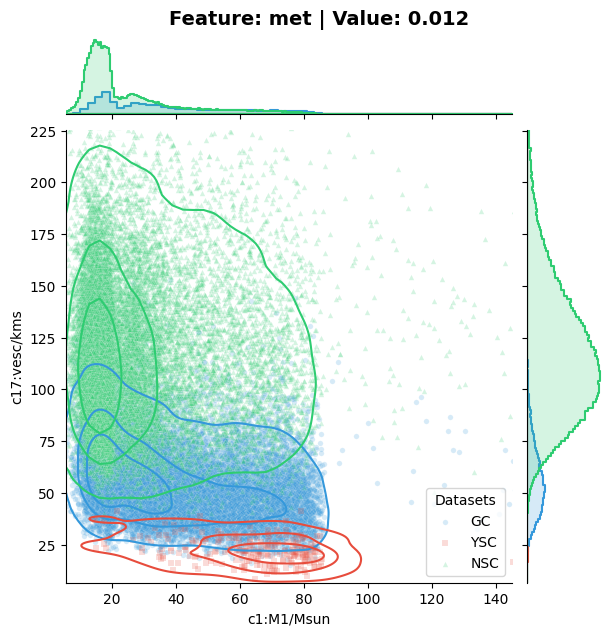

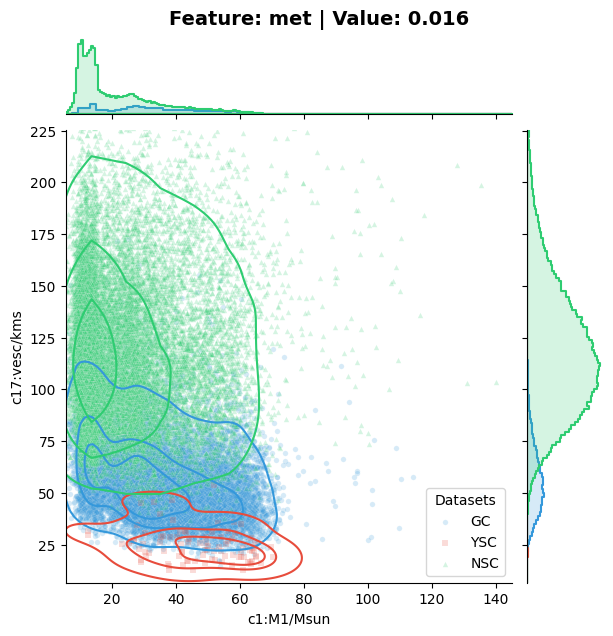

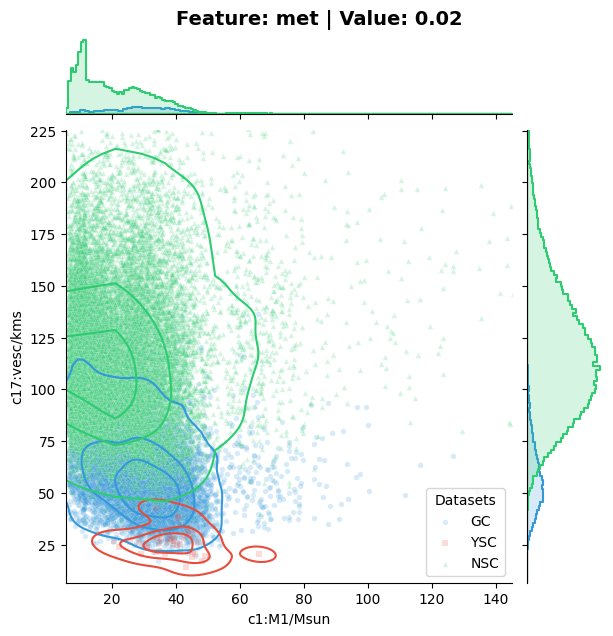

In [21]:
from scipy.stats._continuous_distns import alpha
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_joint_per_category(dfs, labels, x_col, y_col, hue_col, quantile=1):
    # 1. Get all unique values for the category across all datasets
    unique_cats = sorted(pd.concat([d[hue_col] for d in dfs]).unique())
    
    # 2. Global limits (90th percentile) for consistent scale across all plots
    all_x = pd.concat([d[x_col] for d in dfs])
    all_y = pd.concat([d[y_col] for d in dfs])
    x_lim = all_x.quantile(quantile)
    y_lim = all_y.quantile(quantile)
    x_min, y_min = all_x.min(), all_y.min()

    colors = ["#3498db", "#e74c3c", "#2ecc71"] # Blue, Red, Green
    markers = ['o', 's', '^']

    # 3. Create one figure for each category
    for cat in unique_cats:
        # Initialize the JointGrid for this specific category
        g = sns.JointGrid(height=6)
        
        for i, df in enumerate(dfs):
            # Filter the current dataset for the current category
            subset = df[df[hue_col] == cat]
            
            if subset.empty:
                continue
            
            # Sample for the scatter plot (Safety for millions of rows)
            sample_size = min(len(subset), 20000)
            sub_sample = subset.sample(n=sample_size, random_state=42)
            
            # --- Center Plot ---
            sns.scatterplot(data=sub_sample, x=x_col, y=y_col, ax=g.ax_joint,
                            color=colors[i], marker=markers[i], alpha=0.2, 
                            s=15, label=labels[i])
            
            sns.kdeplot(data=sub_sample, x=x_col, y=y_col, ax=g.ax_joint,
                        color=colors[i], levels=4, alpha=1, warn_singular=True)
            
            # --- Marginal Histograms ---
            sns.histplot(data=subset, x=x_col, ax=g.ax_marg_x, color=colors[i],
                         element="step", fill=True, linewidth=1.5, common_norm=False,
                         binrange=(x_min, x_lim), alpha=0.2)
            
            sns.histplot(data=subset, y=y_col, ax=g.ax_marg_y, color=colors[i],
                         element="step", fill=True, linewidth=1.5, common_norm=False,
                         binrange=(y_min, y_lim), alpha=0.2)

        # 4. Final Formatting for this category plot
        g.ax_joint.set_xlim(x_min, x_lim)
        g.ax_joint.set_ylim(y_min, y_lim)
        
        # Set Title and Legend
        plt.suptitle(f"Feature: {hue_col} | Value: {cat}", y=1.02, fontsize=14, fontweight='bold')
        g.ax_joint.legend(title="Datasets", loc='lower right')
        
        plt.show()

# Usage:
plot_joint_per_category([df_GC, df_YSC, df_NSC], ['GC', 'YSC', 'NSC'], 'c1:M1/Msun', 'c17:vesc/kms', 'met',0.99)

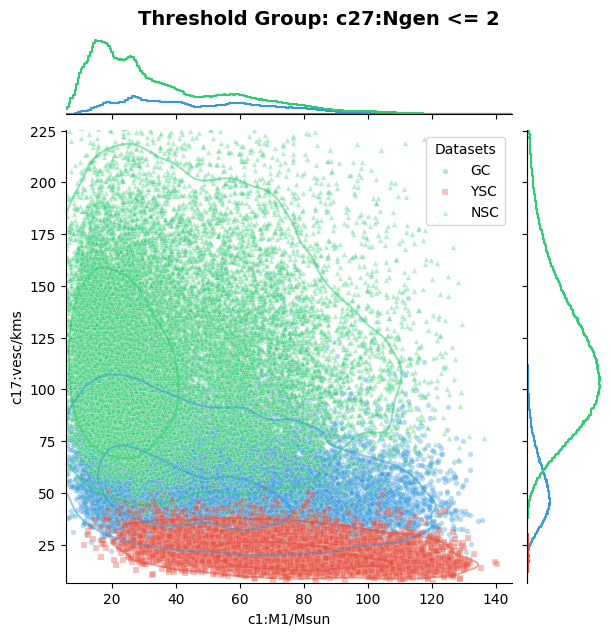

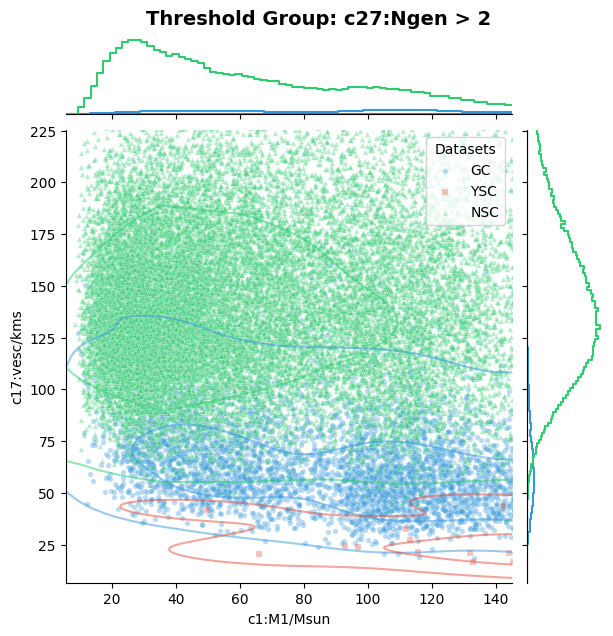

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_joint_threshold_split(dfs, labels, x_col, y_col, hue_col, threshold):
    # 1. Global limits (90th percentile) for consistent scale
    all_x = pd.concat([d[x_col] for d in dfs])
    all_y = pd.concat([d[y_col] for d in dfs])
    x_lim = all_x.quantile(0.99)
    y_lim = all_y.quantile(0.99)
    x_min, y_min = all_x.min(), all_y.min()

    colors = ["#3498db", "#e74c3c", "#2ecc71"] # Blue, Red, Green
    markers = ['o', 's', '^']
    
    # Define the two conditions
    conditions = [
        (lambda x: x <= threshold, f"<= {threshold}"),
        (lambda x: x > threshold, f"> {threshold}")
    ]

    # 2. Loop through the two threshold groups
    for check, cond_name in conditions:
        g = sns.JointGrid(height=6)
        
        for i, df in enumerate(dfs):
            # Apply the threshold filter to the current dataset
            subset = df[check(df[hue_col])]
            
            if subset.empty:
                continue
            
            # Sample for performance (3.2M rows safety)
            sub_sample = subset.sample(n=min(len(subset), 25000), random_state=42)
            
            # --- Center Plot ---
            sns.scatterplot(data=sub_sample, x=x_col, y=y_col, ax=g.ax_joint,
                            color=colors[i], marker=markers[i], alpha=0.35, 
                            s=15, label=labels[i])
            
            sns.kdeplot(data=sub_sample, x=x_col, y=y_col, ax=g.ax_joint,
                        color=colors[i], levels=3, alpha=0.5, warn_singular=True)
            
            # --- Marginal Histograms ---
            sns.histplot(data=subset, x=x_col, ax=g.ax_marg_x, color=colors[i],
                         element="step", fill=False, linewidth=1.5, 
                         common_norm=False, binrange=(x_min, x_lim))
            
            sns.histplot(data=subset, y=y_col, ax=g.ax_marg_y, color=colors[i],
                         element="step", fill=False, linewidth=1.5, 
                         common_norm=False, binrange=(y_min, y_lim))

        # 3. Final Polish for each Threshold Plot
        g.ax_joint.set_xlim(x_min, x_lim)
        g.ax_joint.set_ylim(y_min, y_lim)
        
        plt.suptitle(f"Threshold Group: {hue_col} {cond_name}", y=1.02, 
                     fontsize=14, fontweight='bold')
        g.ax_joint.legend(title="Datasets", loc='upper right')
        
        plt.show()

# Usage:
plot_joint_threshold_split([df_GC, df_YSC, df_NSC], ['GC', 'YSC', 'NSC'], 'c1:M1/Msun', 'c17:vesc/kms', 'c27:Ngen', threshold=2)

## Classification

## Results